### 🎯 Phase 7: Hit Song Prediction (Classification)

Objective: Pivot from Regression to Classification. Predict whether a song will be a "Hit" (Popularity >= 75) or "Non-Hit".

Why Classification? Exact popularity scores are too noisy due to external factors (marketing, movies, virality). Binary classification is more robust and more useful for business decisions (e.g., "Should we promote this track?").

In [1]:
!uv pip install xgboost scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Premium Plot Theme
sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Load Data
df = pd.read_parquet(Path("../data/processed/indian_songs_ml_ready.parquet"))

# Create Binary Target: 1 = Hit (>=75), 0 = Non-Hit (<75)
df['is_hit'] = (df['popularity'] >= 75).astype(int)

print(f"Total Songs: {len(df)}")
print(f"Hits (1): {df['is_hit'].sum()} ({df['is_hit'].mean()*100:.1f}%)")
print(f"Non-Hits (0): {(df['is_hit'] == 0).sum()} ({(1-df['is_hit'].mean())*100:.1f}%)")

Using Python 3.12.7 environment at: /Users/manaskolaskar/Developer/Projects/spotify-india-intelligence/.venv
Checked 2 packages in 36ms
Total Songs: 34999
Hits (1): 12069 (34.5%)
Non-Hits (0): 22930 (65.5%)


In [2]:
# Features and Target
FEATURES = [col for col in df.columns if col not in ['popularity', 'is_hit']]
X = df[FEATURES]
y = df['is_hit']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost Classifier
# Note: scale_pos_weight helps with imbalanced classes (we have more non-hits than hits)
hit_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=hit_ratio, # Handle class imbalance!
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost Classifier...")
xgb_clf.fit(X_train, y_train)
print("✅ Training Complete!")

Training XGBoost Classifier...
✅ Training Complete!


📊 Classification Report:

              precision    recall  f1-score   support

     Non-Hit       0.70      0.61      0.65      4586
         Hit       0.40      0.50      0.45      2414

    accuracy                           0.57      7000
   macro avg       0.55      0.56      0.55      7000
weighted avg       0.60      0.57      0.58      7000



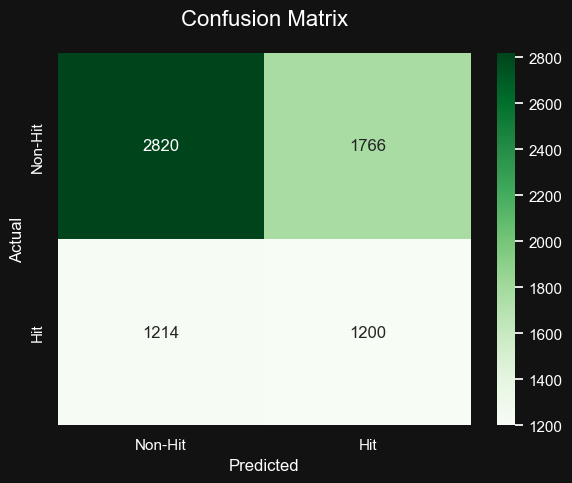

In [3]:
# Predictions
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:, 1] # Probability of being a hit

# Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-Hit', 'Hit']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()